# 07 - Temporal Combination Testing (Monthly)

In [1]:
import sys
sys.path.insert(0, '..')

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time

from src.config import load_config
from src.utils import setup_logging, ensure_dir, save_checkpoint, load_checkpoint
from src.temporal_alignment import generate_period_windows
from src.modeling import nested_cv_pipeline
from src.evaluation import results_summary_table

logger = setup_logging()
config = load_config()
output_dir = config['data']['output_dir']
results_dir = '../models/temporal_combinations'
ensure_dir(results_dir)

AGGREGATION_MODE = config['aggregation']['mode']
windows = generate_period_windows(config)
period_names = [w[0] for w in windows]
print(f"Aggregation mode: {AGGREGATION_MODE}")
print(f"All periods ({len(period_names)}): {period_names}")

# Use ALL periods (full season)
active_periods = period_names
print(f"\nActive periods: {active_periods}")
print(f"Count: {len(active_periods)}")
print(f"Total contiguous combinations: {len(active_periods) * (len(active_periods) + 1) // 2}")

Aggregation mode: monthly
All periods (13): ['mo_m9', 'mo_m8', 'mo_m7', 'mo_m6', 'mo_m5', 'mo_m4', 'mo_m3', 'mo_m2', 'mo_m1', 'mo_peak', 'mo_p1', 'mo_p2', 'mo_p3']

Active periods: ['mo_m9', 'mo_m8', 'mo_m7', 'mo_m6', 'mo_m5', 'mo_m4', 'mo_m3', 'mo_m2', 'mo_m1', 'mo_peak', 'mo_p1', 'mo_p2', 'mo_p3']
Count: 13
Total contiguous combinations: 91


## 1. Load Base Data

In [2]:
# Load engineered features and filter to RAW only
df = pd.read_parquet(f'{output_dir}/engineered_features_{AGGREGATION_MODE}.parquet')

# Identify derived features (mode-agnostic: bw, mo, phenological)
_P = r'(?:bw|mo|tillering|stem_elongation|booting|heading_anthesis|grain_filling|maturity)'
derived_patterns = [
    rf'_(change|ratio|roc)_{_P}',  # Temporal derivatives (all modes)
    r'_div_',                                       # Band ratios
    r'_x_',                                         # Interaction terms
    r'_aridity_idx', r'_water_deficit', r'_heat_stress',  # Agronomic
    r'^pheno_',                                     # Phenological
    r'_seasonal_cv$', r'_seasonal_range$', r'_seasonal_slope$',  # Seasonal
]
is_derived = lambda c: any(re.search(p, c) for p in derived_patterns)

exclude = ['field_key', 'protein_pct', 'yield_bu_ac', 'county', 'state',
           'centroid_lat', 'centroid_lon']
all_feat_cols = [c for c in df.columns
                 if c not in exclude and df[c].dtype in ['int64', 'float64']]
raw_feat_cols = [c for c in all_feat_cols if not is_derived(c)]

# Identify static features (not prefixed by any period)
static_cols = [c for c in raw_feat_cols
               if not any(c.startswith(p + '_') for p in period_names)]

y = df['protein_pct'].values
groups = df['field_key'].values

print(f"Total features: {len(all_feat_cols)}")
print(f"Raw features: {len(raw_feat_cols)} (dropped {len(all_feat_cols) - len(raw_feat_cols)} derived)")
print(f"Static features: {len(static_cols)}")
print(f"Fields: {len(np.unique(groups))}")
print(f"Protein range: {y.min():.1f} - {y.max():.1f}%")

Total features: 3936
Raw features: 1981 (dropped 1955 derived)
Static features: 70
Fields: 228
Protein range: 8.9 - 16.1%


## 2. Generate All Contiguous Combinations

In [3]:
# Generate ALL contiguous combinations from active_periods
# Every possible (start, end) pair where start <= end
combinations = []
combo_labels = []  # (start_period, end_period) for heatmap

for start in range(len(active_periods)):
    for length in range(1, len(active_periods) - start + 1):
        combo = active_periods[start:start + length]
        combinations.append(combo)
        combo_labels.append((combo[0], combo[-1]))

print(f"Total contiguous combinations: {len(combinations)}")
print(f"\nFirst 10:")
for i, (combo, label) in enumerate(zip(combinations[:10], combo_labels[:10])):
    print(f"  {i+1}. {label[0]} \u2192 {label[1]}  ({len(combo)} periods)")

print(f"\nLast 5:")
for i, (combo, label) in enumerate(zip(combinations[-5:], combo_labels[-5:])):
    print(f"  {len(combinations)-4+i}. {label[0]} \u2192 {label[1]}  ({len(combo)} periods)")

Total contiguous combinations: 91

First 10:
  1. mo_m9 → mo_m9  (1 periods)
  2. mo_m9 → mo_m8  (2 periods)
  3. mo_m9 → mo_m7  (3 periods)
  4. mo_m9 → mo_m6  (4 periods)
  5. mo_m9 → mo_m5  (5 periods)
  6. mo_m9 → mo_m4  (6 periods)
  7. mo_m9 → mo_m3  (7 periods)
  8. mo_m9 → mo_m2  (8 periods)
  9. mo_m9 → mo_m1  (9 periods)
  10. mo_m9 → mo_peak  (10 periods)

Last 5:
  87. mo_p1 → mo_p2  (2 periods)
  88. mo_p1 → mo_p3  (3 periods)
  89. mo_p2 → mo_p2  (1 periods)
  90. mo_p2 → mo_p3  (2 periods)
  91. mo_p3 → mo_p3  (1 periods)


## 3. Run Combination Testing

In [4]:
# v3 checkpoint — raw features, full season, Boruta
checkpoint_path = f'{results_dir}/checkpoint_{AGGREGATION_MODE}_v3.json'
checkpoint = load_checkpoint(checkpoint_path)
completed = set(checkpoint.get('completed', []))
all_results = checkpoint.get('results', {})

print(f"Checkpoint loaded: {len(completed)}/{len(combinations)} combinations already completed")
remaining = len(combinations) - len(completed)
print(f"Remaining: {remaining}")
if remaining > 0:
    print(f"Estimated time: ~{remaining * 3:.0f} min ({remaining * 3 / 60:.1f} hours)")

t_total_start = time.time()

for combo_idx, (combo_periods, label) in enumerate(zip(combinations, combo_labels)):
    combo_key = f"{label[0]}__to__{label[1]}"
    
    if combo_key in completed:
        continue
    
    print(f"\n{'=' * 70}")
    print(f"[{combo_idx+1}/{len(combinations)}] {label[0]} \u2192 {label[1]}  ({len(combo_periods)} periods)")
    print(f"{'=' * 70}")
    
    t_start = time.time()
    
    try:
        # 1. Subset raw features to selected periods + static
        period_cols = [c for c in raw_feat_cols
                       if any(c.startswith(p + '_') for p in combo_periods)]
        feat_cols = period_cols + static_cols
        X_combo = df[feat_cols].copy()
        
        print(f"  Features: {X_combo.shape[1]} ({len(period_cols)} temporal + {len(static_cols)} static)")
        
        if X_combo.shape[1] < 5:
            print(f"  Too few features ({X_combo.shape[1]}), skipping")
            completed.add(combo_key)
            save_checkpoint({'completed': list(completed), 'results': all_results}, checkpoint_path)
            continue
        
        # 2. Run nested CV with feature selection INSIDE each fold
        cv_results = nested_cv_pipeline(
            X_combo, y, groups, config,
            run_feature_selection=True,
        )
        
        # Store results
        combo_result = {
            'start_period': label[0],
            'end_period': label[1],
            'periods': combo_periods,
            'n_periods': len(combo_periods),
            'n_features_input': X_combo.shape[1],
        }
        
        # Per-fold feature counts
        if 'per_fold_features' in cv_results:
            fold_feat_counts = [len(f) for f in cv_results['per_fold_features']]
            combo_result['n_features_selected_mean'] = float(np.mean(fold_feat_counts))
            combo_result['n_features_selected_std'] = float(np.std(fold_feat_counts))
        
        for model_name, metrics in cv_results['summary'].items():
            if metrics:
                for metric_name, values in metrics.items():
                    if isinstance(values, list) and len(values) > 0:
                        combo_result[f'{model_name}_{metric_name}_mean'] = float(np.mean(values))
                        combo_result[f'{model_name}_{metric_name}_std'] = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
        
        all_results[combo_key] = combo_result
        completed.add(combo_key)
        
        elapsed = time.time() - t_start
        # Save checkpoint
        save_checkpoint({'completed': list(completed), 'results': all_results}, checkpoint_path)
        
        # Summary line
        best_r2 = max(
            (combo_result.get(f'{m}_R2_mean', -999) for m in ['RandomForest', 'LightGBM', 'XGBoost', 'ElasticNet', 'Stacking', 'Ensemble']),
            default=-999
        )
        print(f"  Done in {elapsed:.0f}s | Best R\u00b2: {best_r2:.4f} | [{len(completed)}/{len(combinations)}]")
        
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback
        traceback.print_exc()
        completed.add(combo_key)
        save_checkpoint({'completed': list(completed), 'results': all_results}, checkpoint_path)
        continue

total_elapsed = time.time() - t_total_start
print(f"\n{'=' * 70}")
print(f"All combinations complete! ({len(completed)}/{len(combinations)})")
print(f"Total time: {total_elapsed/60:.1f} min ({total_elapsed/3600:.1f} hours)")

13:50:32 | INFO    | Nested CV: 5 outer folds, models: ['RandomForest', 'LightGBM', 'XGBoost', 'ElasticNet'] + Stacking


Checkpoint loaded: 49/91 combinations already completed
Remaining: 42
Estimated time: ~126 min (2.1 hours)

[50/91] mo_m5 → mo_m2  (4 periods)
  Features: 658 (588 temporal + 70 static)


13:50:32 | INFO    | Unsupervised prescreening: variance filter (threshold=1.00e-06): 658 → 655 features
13:50:33 | INFO    | Unsupervised prescreening: collinearity filter (threshold=0.90): 655 → 181 features
13:50:33 | INFO    | Unsupervised prescreening complete: 658 → 181 features
13:50:33 | INFO    | Outer CV: StratifiedKFold (shuffle=True, 5 splits, 5 protein bins)
13:50:33 | INFO    | --- Fold 1/5 ---
13:50:33 | INFO    | Feature selection pipeline: 181 input features, 182 samples
13:50:33 | INFO    | Prescreening: disabled
13:51:07 | INFO    | Boruta: 9 confirmed, 1 tentative → 10 selected features
13:51:07 | INFO    | After Boruta: 10 features
13:51:07 | INFO    | Feature selection complete: 181 → 10 features
13:51:07 | INFO    |   Feature selection: 181 → 10 features
13:51:56 | INFO    |   RandomForest — best params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 5} | Test R²: 0.1200 | Test RMSE: 1.2349
c:\Users\Vlasis\miniconda3\Lib\site-packages\sklearn\utils\val

  Done in 623s | Best R²: 0.1001 | [50/91]

[51/91] mo_m5 → mo_m1  (5 periods)
  Features: 805 (735 temporal + 70 static)


14:00:56 | INFO    | Unsupervised prescreening: collinearity filter (threshold=0.90): 802 → 225 features
14:00:56 | INFO    | Unsupervised prescreening complete: 805 → 225 features
14:00:56 | INFO    | Outer CV: StratifiedKFold (shuffle=True, 5 splits, 5 protein bins)
14:00:56 | INFO    | --- Fold 1/5 ---
14:00:56 | INFO    | Feature selection pipeline: 225 input features, 182 samples
14:00:56 | INFO    | Prescreening: disabled
14:01:39 | INFO    | Boruta: 9 confirmed, 3 tentative → 12 selected features
14:01:39 | INFO    | After Boruta: 12 features
14:01:39 | INFO    | Feature selection complete: 225 → 12 features
14:01:39 | INFO    |   Feature selection: 225 → 12 features
14:02:19 | INFO    |   RandomForest — best params: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': None} | Test R²: 0.1722 | Test RMSE: 1.1977
c:\Users\Vlasis\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with f

...

  Done in 1187s | Best R²: 0.1394 | [89/91]

[90/91] mo_p2 → mo_p3  (2 periods)
  Features: 364 (294 temporal + 70 static)


03:25:42 | INFO    | Unsupervised prescreening: collinearity filter (threshold=0.90): 355 → 108 features
03:25:42 | INFO    | Unsupervised prescreening complete: 364 → 108 features
03:25:42 | INFO    | Outer CV: StratifiedKFold (shuffle=True, 5 splits, 5 protein bins)
03:25:42 | INFO    | --- Fold 1/5 ---
03:25:42 | INFO    | Feature selection pipeline: 108 input features, 182 samples
03:25:42 | INFO    | Prescreening: disabled
03:26:18 | INFO    | Boruta: 5 confirmed, 3 tentative → 8 selected features
03:26:18 | INFO    | After Boruta: 8 features
03:26:18 | INFO    | Feature selection complete: 108 → 8 features
03:26:18 | INFO    |   Feature selection: 108 → 8 features
03:27:02 | INFO    |   RandomForest — best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 10} | Test R²: 0.0595 | Test RMSE: 1.2766
c:\Users\Vlasis\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature

  Done in 1238s | Best R²: 0.1433 | [90/91]

[91/91] mo_p3 → mo_p3  (1 periods)
  Features: 217 (147 temporal + 70 static)


03:46:42 | INFO    | Boruta: 4 confirmed, 0 tentative → 4 selected features
03:46:42 | INFO    | After Boruta: 4 features
03:46:42 | INFO    | Feature selection complete: 58 → 4 features
03:46:42 | INFO    |   Feature selection: 58 → 4 features
03:47:32 | INFO    |   RandomForest — best params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 5} | Test R²: 0.1022 | Test RMSE: 1.2473
c:\Users\Vlasis\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Vlasis\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
03:48:20 | INFO    |   LightGBM — best params: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.01} | Test R²: 0.0491 | Test RMSE: 1.2836
03:48:41 | INFO    |   XGBoost — b

  Done in 1009s | Best R²: 0.0958 | [91/91]

All combinations complete! (91/91)
Total time: 852.6 min (14.2 hours)


## 4. Results Comparison

In [1]:
# Build results table
if all_results:
    results_list = []
    for combo_key, result in all_results.items():
        row = {
            'Start': result['start_period'],
            'End': result['end_period'],
            'N_Periods': result['n_periods'],
            'N_Features_Input': result['n_features_input'],
            'N_Features_Selected': result.get('n_features_selected_mean', np.nan),
        }
        # Extract R2 mean for each model
        for model in ['RandomForest', 'LightGBM', 'XGBoost', 'ElasticNet', 'Stacking', 'Ensemble']:
            r2_key = f'{model}_R2_mean'
            rmse_key = f'{model}_RMSE_mean'
            if r2_key in result:
                row[f'{model}_R2'] = result[r2_key]
            if rmse_key in result:
                row[f'{model}_RMSE'] = result[rmse_key]
        results_list.append(row)
    
    results_table = pd.DataFrame(results_list)
    
    # Best R2 across all models
    r2_cols = [c for c in results_table.columns if c.endswith('_R2')]
    if r2_cols:
        results_table['Best_R2'] = results_table[r2_cols].max(axis=1)
        results_table['Best_Model'] = results_table[r2_cols].idxmax(axis=1).str.replace('_R2', '')
    
    # Sort by best R2
    results_table = results_table.sort_values('Best_R2', ascending=False)
    
    print("Top 15 temporal windows by best R\u00b2:")
    print("=" * 100)
    display_cols = ['Start', 'End', 'N_Periods', 'N_Features_Selected', 'Best_R2', 'Best_Model'] + r2_cols
    display_cols = [c for c in display_cols if c in results_table.columns]
    print(results_table[display_cols].head(15).to_string(index=False, float_format='%.4f'))
    
    print(f"\nTotal combinations evaluated: {len(results_table)}")
else:
    print("No results yet \u2014 run cell 3 first.")

NameError: name 'all_results' is not defined

## 5. Visualization: Heatmap of Start × End → R²

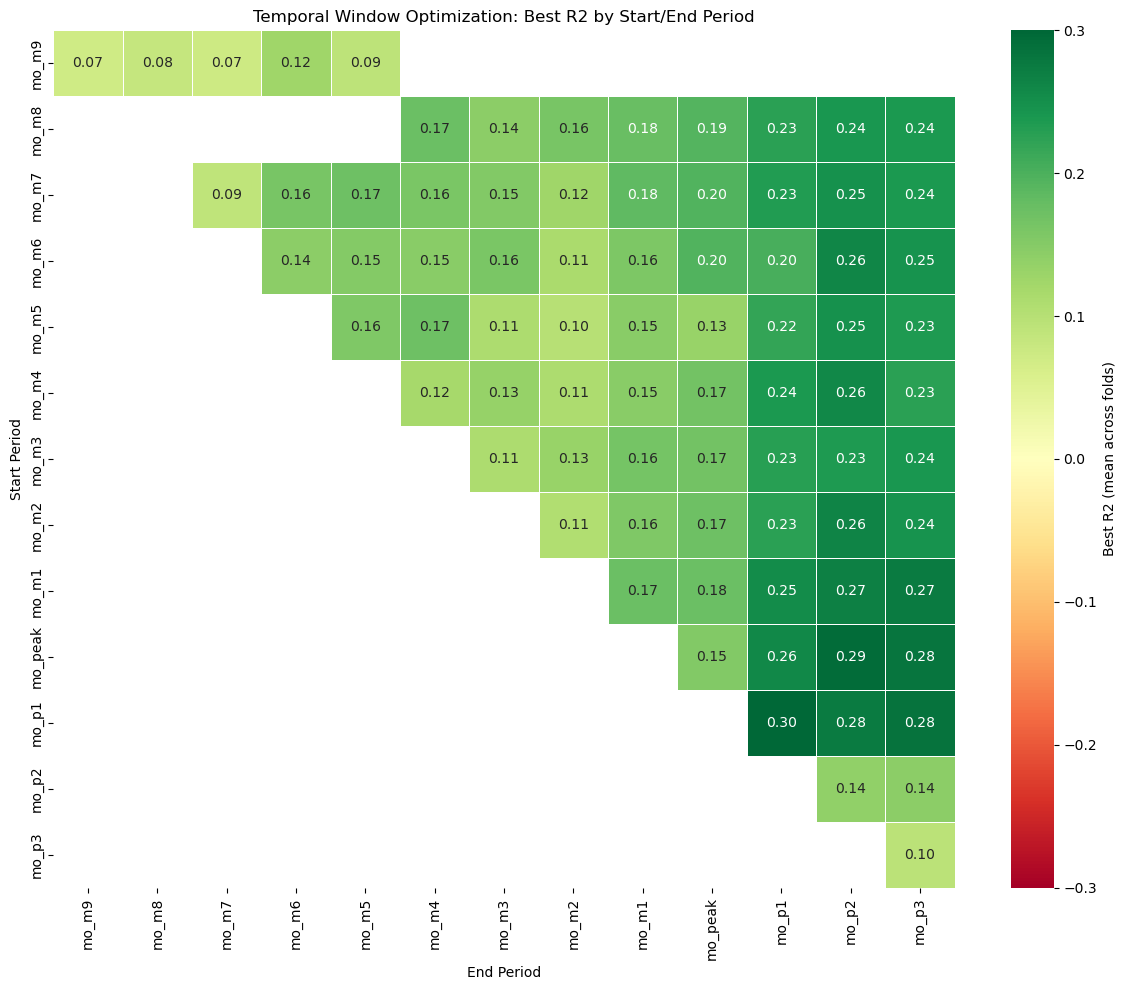

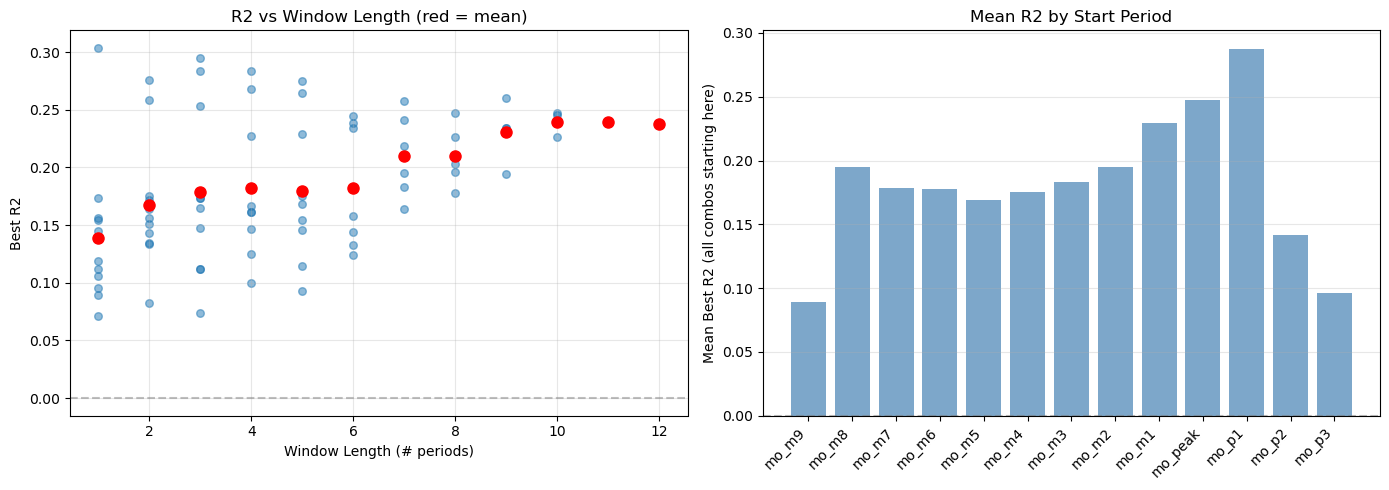

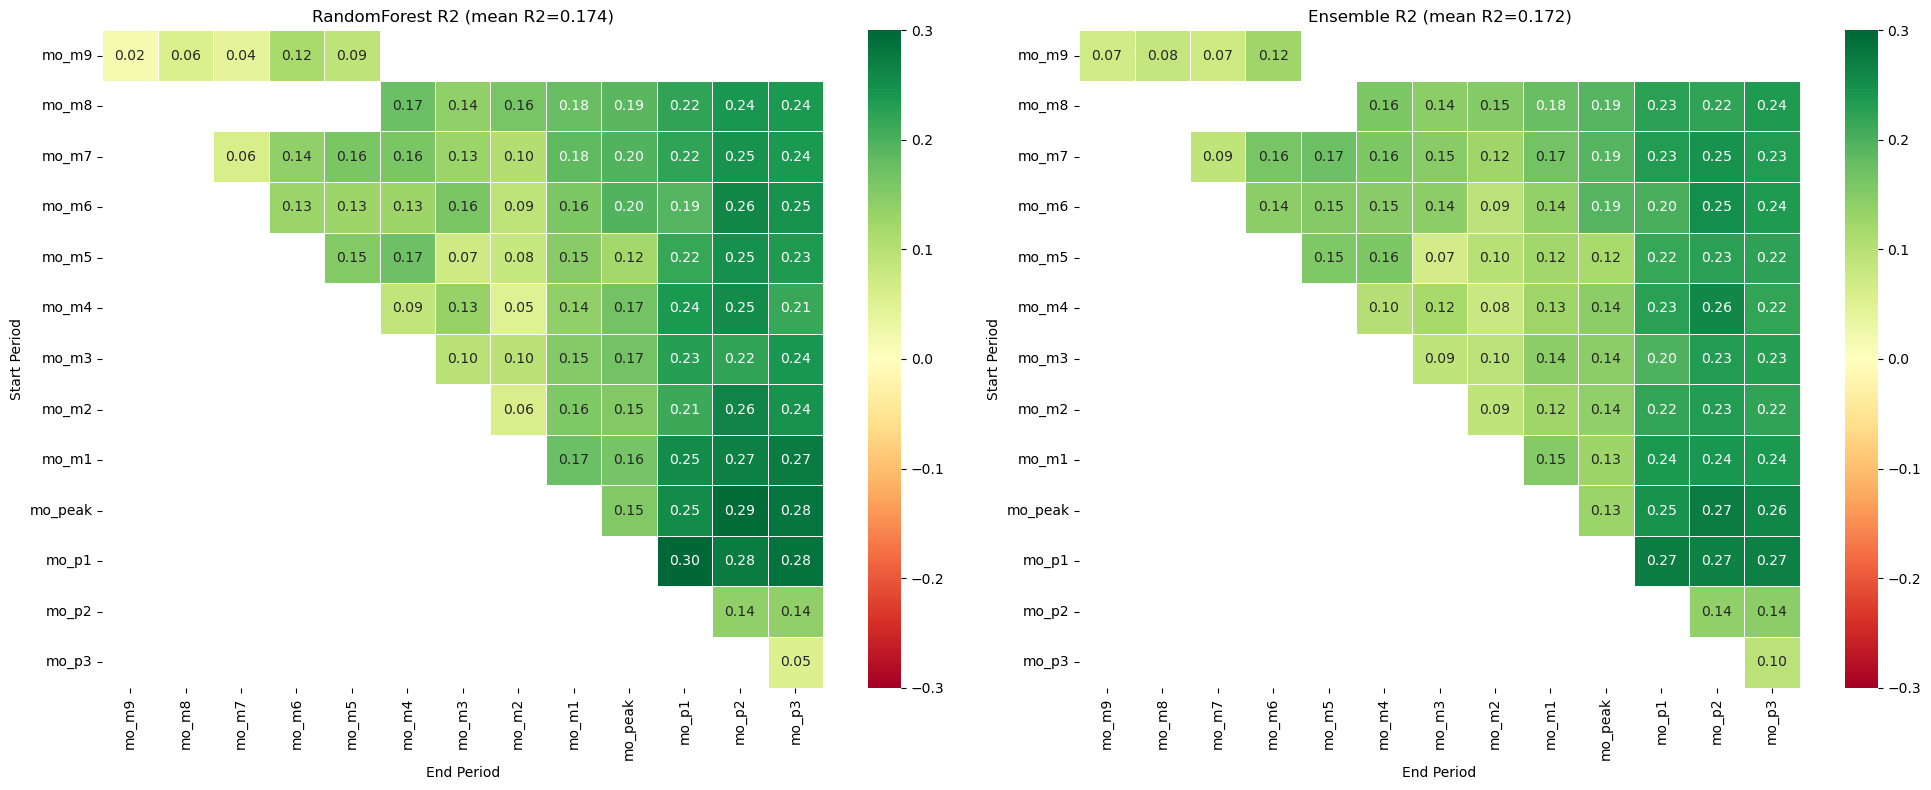

In [6]:
if all_results:
    ensure_dir('../figures')
    
    # --- 1. HEATMAP: Start x End -> Best R2 ---
    heatmap_data = pd.DataFrame({
        'Start': [r['start_period'] for r in all_results.values()],
        'End': [r['end_period'] for r in all_results.values()],
    })
    
    # Compute best R2 across all models for each combo
    best_r2s = []
    for r in all_results.values():
        r2_vals = [r.get(f'{m}_R2_mean', -999) 
                   for m in ['RandomForest', 'LightGBM', 'XGBoost', 'ElasticNet', 'Stacking', 'Ensemble']]
        best_r2s.append(max(r2_vals))
    heatmap_data['Best_R2'] = best_r2s
    
    pivot = heatmap_data.pivot_table(index='Start', columns='End', values='Best_R2')
    # Reorder axes to match temporal order
    pivot = pivot.reindex(index=active_periods, columns=active_periods)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = pivot.isna()  # Mask invalid combos (start > end)
    sns.heatmap(
        pivot, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
        center=0, vmin=-0.3, vmax=0.3,
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Best R2 (mean across folds)'},
    )
    ax.set_xlabel('End Period')
    ax.set_ylabel('Start Period')
    ax.set_title('Temporal Window Optimization: Best R2 by Start/End Period')
    plt.tight_layout()
    plt.savefig('../figures/07_heatmap_temporal_r2.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- 2. R2 vs Window Length ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    lengths = [r['n_periods'] for r in all_results.values()]
    
    # Best R2 vs length
    axes[0].scatter(lengths, best_r2s, alpha=0.5, s=30)
    # Add trend line
    for n in sorted(set(lengths)):
        vals = [r2 for r2, l in zip(best_r2s, lengths) if l == n]
        axes[0].plot(n, np.mean(vals), 'ro', markersize=8, zorder=5)
    axes[0].set_xlabel('Window Length (# periods)')
    axes[0].set_ylabel('Best R2')
    axes[0].set_title('R2 vs Window Length (red = mean)')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].grid(True, alpha=0.3)
    
    # Best R2 by start period
    start_means = {}
    for r, r2 in zip(all_results.values(), best_r2s):
        s = r['start_period']
        start_means.setdefault(s, []).append(r2)
    
    start_periods_ordered = [p for p in active_periods if p in start_means]
    start_mean_vals = [np.mean(start_means[p]) for p in start_periods_ordered]
    
    axes[1].bar(range(len(start_periods_ordered)), start_mean_vals, color='steelblue', alpha=0.7)
    axes[1].set_xticks(range(len(start_periods_ordered)))
    axes[1].set_xticklabels(start_periods_ordered, rotation=45, ha='right')
    axes[1].set_ylabel('Mean Best R2 (all combos starting here)')
    axes[1].set_title('Mean R2 by Start Period')
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../figures/07_temporal_window_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- 3. Per-model heatmaps (top 2 models) ---
    model_names = ['RandomForest', 'LightGBM', 'XGBoost', 'ElasticNet', 'Stacking', 'Ensemble']
    model_mean_r2 = {}
    for m in model_names:
        vals = [r.get(f'{m}_R2_mean', np.nan) for r in all_results.values()]
        vals = [v for v in vals if not np.isnan(v)]
        if vals:
            model_mean_r2[m] = np.mean(vals)
    
    top_models = sorted(model_mean_r2, key=model_mean_r2.get, reverse=True)[:2]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, model in zip(axes, top_models):
        hm = pd.DataFrame({
            'Start': [r['start_period'] for r in all_results.values()],
            'End': [r['end_period'] for r in all_results.values()],
            'R2': [r.get(f'{model}_R2_mean', np.nan) for r in all_results.values()],
        })
        piv = hm.pivot_table(index='Start', columns='End', values='R2')
        piv = piv.reindex(index=active_periods, columns=active_periods)
        
        sns.heatmap(
            piv, mask=piv.isna(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.5, ax=ax,
        )
        ax.set_title(f'{model} R2 (mean R2={model_mean_r2[model]:.3f})')
        ax.set_xlabel('End Period')
        ax.set_ylabel('Start Period')
    
    plt.tight_layout()
    plt.savefig('../figures/07_heatmap_per_model.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No results yet.")

## 6. Save Final Results

In [ ]:
# Save comprehensive results
output_path = f'{results_dir}/results_all_{AGGREGATION_MODE}_v3.csv'
if all_results:
    results_df = pd.DataFrame([
        {**{'combo': k}, **{kk: vv for kk, vv in v.items() if kk not in ['selected_features', 'periods']}}
        for k, v in all_results.items()
    ])
    results_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")
    
    # Find best combination per model
    print(f"\nBest temporal window per model:")
    print("=" * 80)
    for model in ['RandomForest', 'LightGBM', 'XGBoost', 'ElasticNet', 'Stacking', 'Ensemble']:
        r2_col = f'{model}_R2_mean'
        if r2_col in results_df.columns:
            best_idx = results_df[r2_col].idxmax()
            best_row = results_df.loc[best_idx]
            print(f"  {model:15s}: {best_row['start_period']} -> {best_row['end_period']}  "
                  f"(R2={best_row[r2_col]:.4f}, {int(best_row['n_periods'])} periods)")
